<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Vacuum Neutrino Analysis 2 — Experimental Regimes and Flux
---

This notebook applies the vacuum oscillation framework to three experimental regimes:
reactor antineutrinos, long-baseline accelerator beams (T2K, NOvA, DUNE), and atmospheric
neutrinos. It uses the `vacuum_flux` API to propagate spectral fluxes to the detector,
illustrating how the oscillation maximum depends on both energy and baseline.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — reactor spectrum, accelerator beams, atmospheric production, vacuum_flux |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** — experiment baselines and spectral parameters |
| [3](#3.-Reactor-Antineutrinos) | **Reactor Antineutrinos** — ν̄e survival vs L and L/E, flux spectrum at detector |
| [4](#4.-Long-Baseline-Accelerator) | **Long-Baseline Accelerator** — νμ survival and νe appearance at T2K, NOvA, DUNE |
| [5](#5.-Atmospheric-Neutrinos) | **Atmospheric Neutrinos** — P(E, cos θz) map and zenith-angle slices |
| [6](#6.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Reactor Antineutrino Sources

Nuclear reactors produce $\bar\nu_e$ from beta decay of fission products. The emitted spectrum
peaks around $E \sim 3$–4 MeV. An approximate spectral shape (Vogel–Beacom inspired) for
the detectable spectrum (above the inverse-beta-decay threshold at 1.8 MeV) is:

$$
\frac{dN}{dE} \propto (E - 1.8)^2 \cdot E^{-1}, \qquad E > 1.8 \; \text{MeV}
$$

Two distinct oscillation effects are relevant:
- At short baselines (< 2 km): only $\Delta m^2_{31}$ drives rapid oscillation of $\bar\nu_e$
  survival.
- At medium baselines (∼50–100 km, e.g. Daya Bay, RENO): optimal for $\theta_{13}$ measurement.
- At long baselines (∼180 km, KamLAND): primarily sensitive to $\Delta m^2_{21}$ and $\theta_{12}$.

### 0.2 Accelerator Neutrino Beams

Long-baseline accelerator experiments produce a $\nu_\mu$ (or $\bar\nu_\mu$) beam from
pion decay in a decay tunnel. The baseline is chosen to maximise oscillation effects:

$$
E_{\rm peak} \approx \frac{\Delta m^2_{31} L}{2\pi \times 1.2669} \times \pi
$$

Key experiments:
- **T2K**: L=295 km, E_peak~0.6 GeV (νμ disappearance, νe appearance)
- **NOvA**: L=810 km, E_peak~1.8 GeV (νe appearance, MO sensitivity)
- **DUNE**: L=1300 km, E_peak~2.5 GeV (wide-band beam, full oscillation maximum visible)

### 0.3 Atmospheric Neutrino Geometry

Atmospheric neutrinos are produced by cosmic-ray interactions in the upper atmosphere (height
$h \approx 20$ km). The baseline from production to an underground detector depends on the
zenith angle $\theta_z$:

$$
L(\theta_z) = \sqrt{(R_E+h)^2 - R_E^2 \sin^2\theta_z} - R_E \cos\theta_z
$$

where $R_E = 6371$ km. This gives $L \approx 20$ km for near-vertical downgoing neutrinos
($\cos\theta_z = +1$) and $L \approx 12\,740$ km for vertically upgoing neutrinos
($\cos\theta_z = -1$, traversing the full Earth diameter).

### 0.4 `vacuum_flux` API

`vacuum_flux(nustate, oscillation, E_MeV, L_km, flux, spectrum=None)` returns the oscillated
flux per flavour:

$$
\Phi^{(\beta)}(E) = P(\nu_\alpha \to \nu_\beta) \times \Phi_0(E)
$$

where `flux` is the total normalisation $\Phi_0$ and `spectrum` is the optional spectral weight
$s(E)$ such that the integrated spectrum equals 1. If `spectrum=None`, a flat spectrum is used.

### References

[1] P. Vogel & J.F. Beacom, Phys. Rev. D **60**, 053003 (1999).
[2] B. Pontecorvo, Sov. Phys. JETP **26**, 984 (1968).
[3] M. Honda et al., Phys. Rev. D **92**, 023004 (2015).

## 1. Libraries

In [1]:
from __future__ import annotations

import dataclasses
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.vacuum.probability import vacuum_probability, pvacuum
from tpeanuts.medium.vacuum.flux import vacuum_flux
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_LABELS, FLAVOUR_COLORS, to_numpy, save_and_show,
)
from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.math import numpy_trapezoid


## 2. Configuration

### 2.1 Paths

In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "vacuum")
SHOW_PLOTS = config.show_plots

print("Output directory:", OUTPUT_DIR)

Output directory: v:\output\analysis\vacuum


### 2.2 Configuration

Experiments dictionary with baseline, beam energy, and display color.
Reactor detector dict for comparison at near, medium, and far distances.

In [3]:
osc     = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
osc_bar = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=True,  context=ctx)

# Long-baseline experiments
EXPERIMENTS = {
    "T2K":  {"L_km": 295,  "E_peak_GeV": 0.6,  "color": "C0"},
    "NOvA": {"L_km": 810,  "E_peak_GeV": 1.8,  "color": "C1"},
    "DUNE": {"L_km": 1300, "E_peak_GeV": 2.5,  "color": "C2"},
}

# Reactor detectors
REACTOR_DETECTORS = {
    "Near (1.5 km)":      {"L_km": 1.5,   "color": "C0", "ls": "-"},
    "Daya Bay (50 km)":   {"L_km": 50.0,  "color": "C1", "ls": "--"},
    "KamLAND (180 km)":   {"L_km": 180.0, "color": "C2", "ls": ":"},
}

R_E = 6371.0   # Earth radius [km]
H_ATM = 20.0   # Production height [km]

def baseline_from_zenith(cos_theta_z: float) -> float:
    # Compute atmospheric baseline in km from cosine of zenith angle
    sin_theta_z = math.sqrt(max(0.0, 1.0 - cos_theta_z**2))
    return math.sqrt((R_E + H_ATM)**2 - (R_E * sin_theta_z)**2) - R_E * cos_theta_z

print("Experiment baselines:")
for name, props in EXPERIMENTS.items():
    print(f"  {name}: L={props['L_km']} km, E_peak={props['E_peak_GeV']} GeV")

print("\nAtmospheric baselines:")
for cz in [-1.0, 0.0, 0.5, 0.9]:
    print(f"  cos(theta_z)={cz:+.1f} -> L={baseline_from_zenith(cz):.0f} km")

Experiment baselines:
  T2K: L=295 km, E_peak=0.6 GeV
  NOvA: L=810 km, E_peak=1.8 GeV
  DUNE: L=1300 km, E_peak=2.5 GeV

Atmospheric baselines:
  cos(theta_z)=-1.0 -> L=12762 km
  cos(theta_z)=+0.0 -> L=505 km
  cos(theta_z)=+0.5 -> L=40 km
  cos(theta_z)=+0.9 -> L=22 km


## 3. Reactor Antineutrinos

### 3.1 ν̄e Survival vs Baseline

ν̄e survival probability as a function of baseline at fixed effective energy E=3 MeV. Three
detector distances are marked: near detector (1.5 km), Daya Bay (50 km), KamLAND (180 km).

**Expected results:** At 1.5 km the probability is close to 1 (little oscillation from Dm31 yet).
At 50 km a dip driven by Dm31 is visible. At 180 km the dominant modulation is from Dm21
(solar splitting), characteristic of the KamLAND signal.

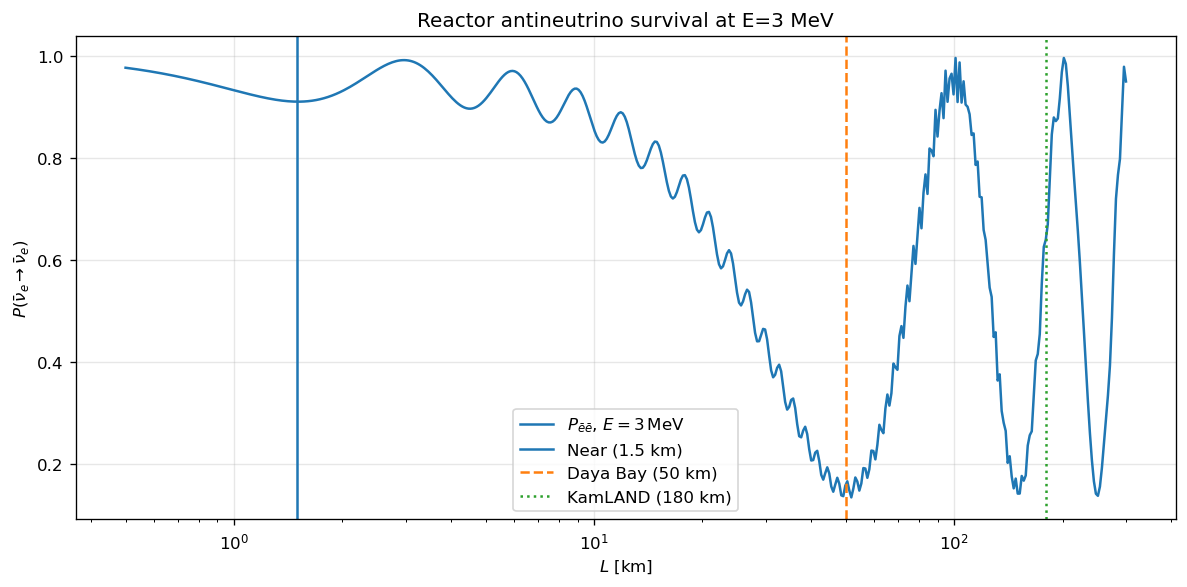

v:\output\analysis\vacuum\vf2_fig31_1_reactor_vs_L.png


In [4]:
E_reactor = torch.tensor(3.0, dtype=ctx.dtype, device=ctx.device)   # MeV
L_reactor = torch.logspace(math.log10(0.5), math.log10(300.0), 500,
                            dtype=ctx.dtype, device=ctx.device)

P_ee_bar = to_numpy(vacuum_probability(osc_bar, E_reactor, L_reactor)[:, 0, 0])
L_r_np   = to_numpy(L_reactor)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(L_r_np, P_ee_bar, color="C0", label=r"$P_{\bar{e}\bar{e}}$, $E=3\,\mathrm{MeV}$")
for name, props in REACTOR_DETECTORS.items():
    ax.axvline(props["L_km"], color=props["color"], ls=props["ls"], label=name)
ax.set_xlabel(r"$L$ [km]")
ax.set_ylabel(r"$P(\bar\nu_e \to \bar\nu_e)$")
ax.set_title("Reactor antineutrino survival at E=3 MeV")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig31_1_reactor_vs_L.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Universal L/E Plot

P_ēē vs L/E reveals both oscillation dips on a single axis. This is the characteristic
observable used by reactor experiments since it scales out the energy dependence.

**Expected results:** Two dips appear: the first from Δm²_31 at L/E ≈ 500 km/GeV (≈ 0.5 km/MeV),
and the deeper dip from Δm²_21 at L/E ≈ 20 000 km/GeV (20 km/MeV), corresponding to the
KamLAND measurement.

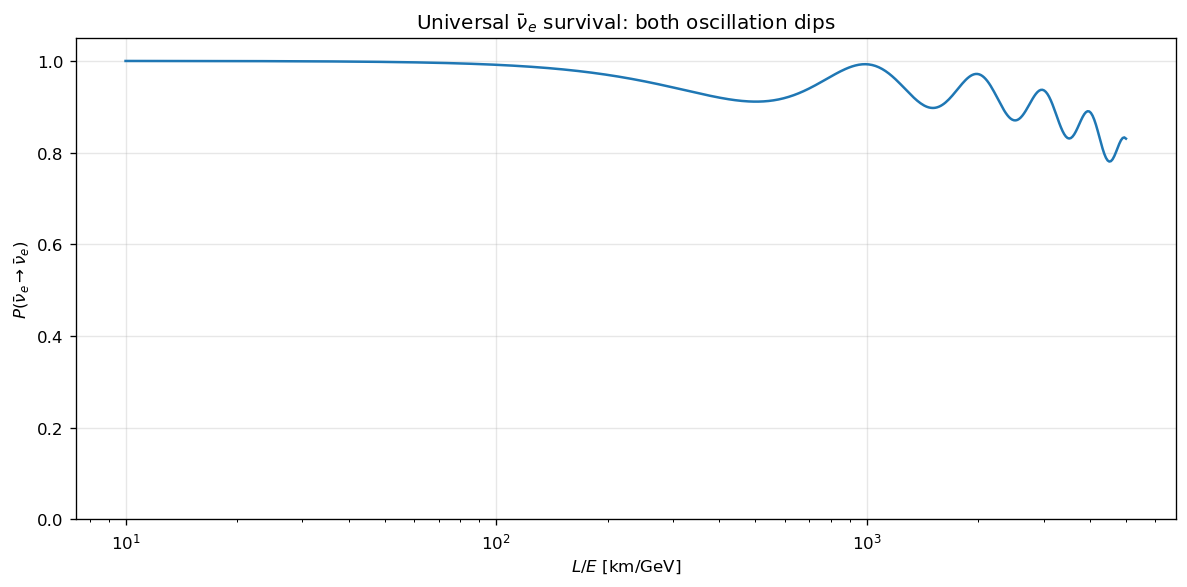

v:\output\analysis\vacuum\vf2_fig32_1_reactor_vs_LoverE.png


In [5]:
# L/E grid spanning both oscillation dips
LoE_grid = np.logspace(math.log10(10.0), math.log10(5000.0), 600)  # km/GeV = m/MeV * 1000

# Use a fixed E and vary L = LoE * E
E_fix_MeV = 3.0
L_from_LoE = torch.tensor(LoE_grid * E_fix_MeV * 1e-3, dtype=ctx.dtype, device=ctx.device)  # km
E_fix_t    = torch.tensor(E_fix_MeV, dtype=ctx.dtype, device=ctx.device)

P_ee_LoE = to_numpy(vacuum_probability(osc_bar, E_fix_t, L_from_LoE)[:, 0, 0])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(LoE_grid, P_ee_LoE, color="C0")
ax.set_xlabel(r"$L/E$ [km/GeV]")
ax.set_ylabel(r"$P(\bar\nu_e \to \bar\nu_e)$")
ax.set_title(r"Universal $\bar\nu_e$ survival: both oscillation dips")
ax.set_ylim(0, 1.05)
fig.tight_layout()
save_and_show("vf2_fig32_1_reactor_vs_LoverE.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.3 Reactor Flux Spectrum

`vacuum_flux` is used to compute the oscillated ν̄e flux spectrum at the near (L=1.5 km) and
KamLAND (L=180 km) detectors. The input spectrum follows a Vogel–Beacom-inspired shape.

**Expected results:** At the near detector the spectrum is nearly unchanged (oscillation barely
started). At KamLAND the ν̄e component is strongly suppressed at all energies above ~3 MeV,
replaced by flavour-converted flux. The other flavour components are tiny since reactor sources
only produce ν̄e.

G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\util\type.py:127: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\Copy.cpp:300.)
  t = t.to(dtype=dtype)


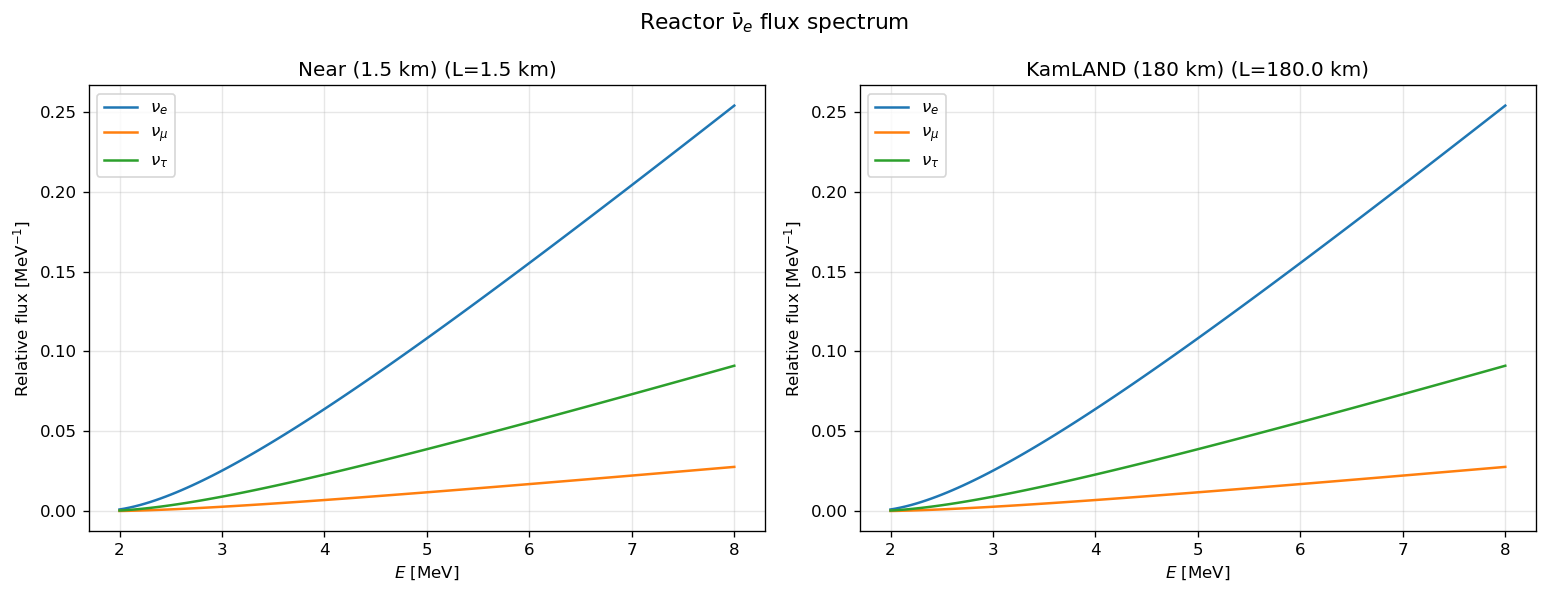

v:\output\analysis\vacuum\vf2_fig33_1_reactor_flux_spectrum.png


In [6]:
E_spec_MeV = np.linspace(2.0, 8.0, 120)
# Vogel-Beacom-inspired shape: dN/dE ∝ (E-1.8)^2 * E^{-1}
spectrum_raw = (E_spec_MeV - 1.8)**2 / E_spec_MeV
spectrum_raw = spectrum_raw / numpy_trapezoid(spectrum_raw, E_spec_MeV)   # normalise

E_t   = torch.tensor(E_spec_MeV, dtype=ctx.dtype, device=ctx.device)
spec_t = torch.tensor(spectrum_raw, dtype=ctx.dtype, device=ctx.device)

# ν̄e initial state (pure flavour state)
nustate_ebar = torch.tensor([1.0 + 0j, 0.0, 0.0], dtype=torch.complex128, device=ctx.device)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, (name, props) in zip(axes, list(REACTOR_DETECTORS.items())[::2]):  # near and KamLAND
    L_t = torch.tensor(props["L_km"], dtype=ctx.dtype, device=ctx.device)
    flux_arr = to_numpy(vacuum_flux(nustate_ebar, osc_bar, E_t, L_t, flux=1.0, spectrum=spec_t))
    for i, (label, color) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
        if flux_arr[:, i].max() > 1e-6:
            ax.plot(E_spec_MeV, flux_arr[:, i], label=label, color=color)
    ax.set_xlabel(r"$E$ [MeV]")
    ax.set_ylabel("Relative flux [MeV$^{-1}$]")
    ax.set_title(f"{name} (L={props['L_km']} km)")
    ax.legend()
fig.suptitle(r"Reactor $\bar\nu_e$ flux spectrum", fontsize=13)
fig.tight_layout()
save_and_show("vf2_fig33_1_reactor_flux_spectrum.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Long-Baseline Accelerator

### 4.1 νμ Survival at T2K, NOvA, DUNE

νμ survival probability P_μμ(E) at the three long-baseline experiments.

**Expected results:** Each experiment shows a characteristic dip at the oscillation maximum
energy E = Δm²_31 L / (2π × 1.2669). T2K's dip is at ~0.6 GeV, NOvA's at ~1.8 GeV, and
DUNE's at ~2.5 GeV. DUNE also shows a second dip at a lower energy, corresponding to the
second oscillation maximum.

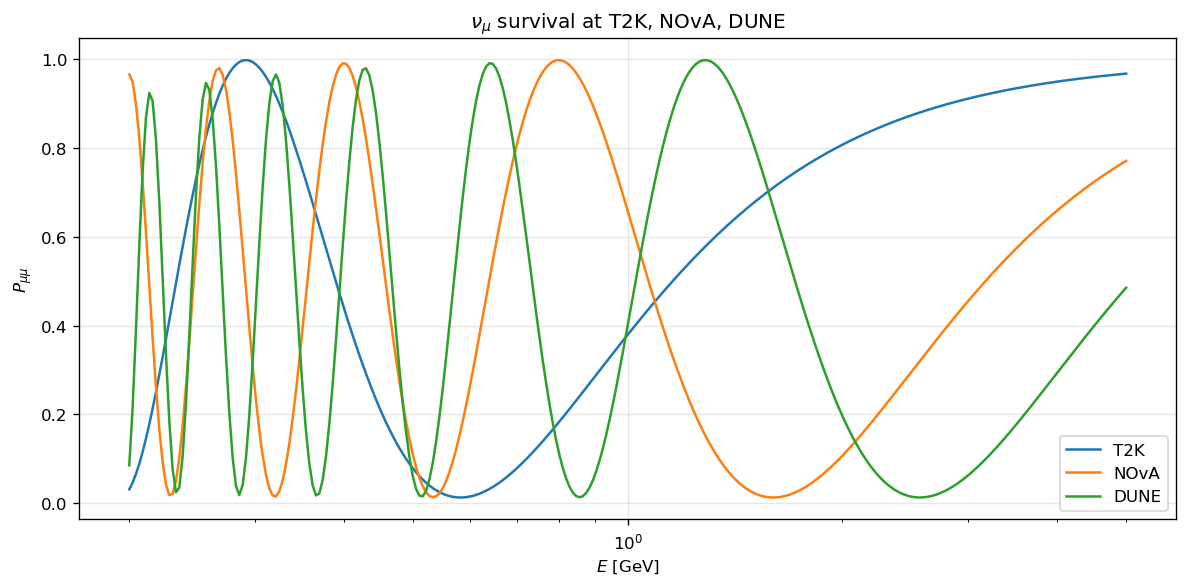

v:\output\analysis\vacuum\vf2_fig41_1_lbl_survival.png


In [7]:
E_lbl = torch.logspace(math.log10(200.0), math.log10(5000.0), 300,
                        dtype=ctx.dtype, device=ctx.device)  # MeV
E_lbl_GeV = to_numpy(E_lbl) * 1e-3

fig, ax = plt.subplots(figsize=(10, 5))
for name, props in EXPERIMENTS.items():
    L_t = torch.tensor(float(props["L_km"]), dtype=ctx.dtype, device=ctx.device)
    P_mm = to_numpy(vacuum_probability(osc, E_lbl, L_t)[:, 1, 1])
    ax.semilogx(E_lbl_GeV, P_mm, label=name, color=props["color"])
ax.set_xlabel(r"$E$ [GeV]")
ax.set_ylabel(r"$P_{\mu\mu}$")
ax.set_title(r"$\nu_\mu$ survival at T2K, NOvA, DUNE")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig41_1_lbl_survival.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 4.2 νe Appearance at T2K, NOvA, DUNE

νμ→νe appearance probability at the three experiments. The vertical dashed lines mark each
experiment's oscillation maximum energy.

**Expected results:** The oscillation maximum P_μe peak is at the same energy where P_μμ shows
its minimum. DUNE has the largest statistics among the three experiments at similar peak
probability values (~0.05–0.09).

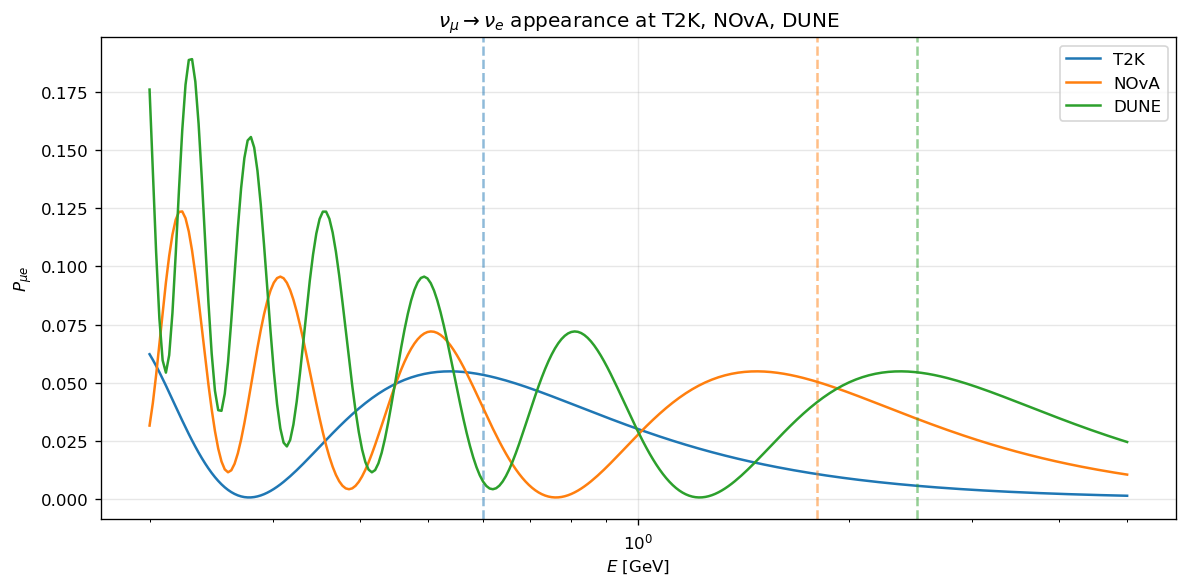

v:\output\analysis\vacuum\vf2_fig42_1_lbl_appearance.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, props in EXPERIMENTS.items():
    L_t   = torch.tensor(float(props["L_km"]), dtype=ctx.dtype, device=ctx.device)
    P_mue = to_numpy(vacuum_probability(osc, E_lbl, L_t)[:, 0, 1])  # P[beta=e, alpha=mu]
    ax.semilogx(E_lbl_GeV, P_mue, label=name, color=props["color"])
    E_max = props["E_peak_GeV"]
    ax.axvline(E_max, color=props["color"], ls="--", alpha=0.5)
ax.set_xlabel(r"$E$ [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title(r"$\nu_\mu \to \nu_e$ appearance at T2K, NOvA, DUNE")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig42_1_lbl_appearance.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 4.3 DUNE νe Appearance Flux

`vacuum_flux` is used to compute the νe appearance flux at the DUNE detector, starting from an
initial νμ state and a Gaussian beam spectrum centred at 2.4 GeV.

**Expected results:** The oscillated νe flux peaks near the first oscillation maximum energy
(~2–3 GeV). The νμ component (survival) shows a corresponding dip. The ντ component is small
but non-zero due to three-flavour mixing.

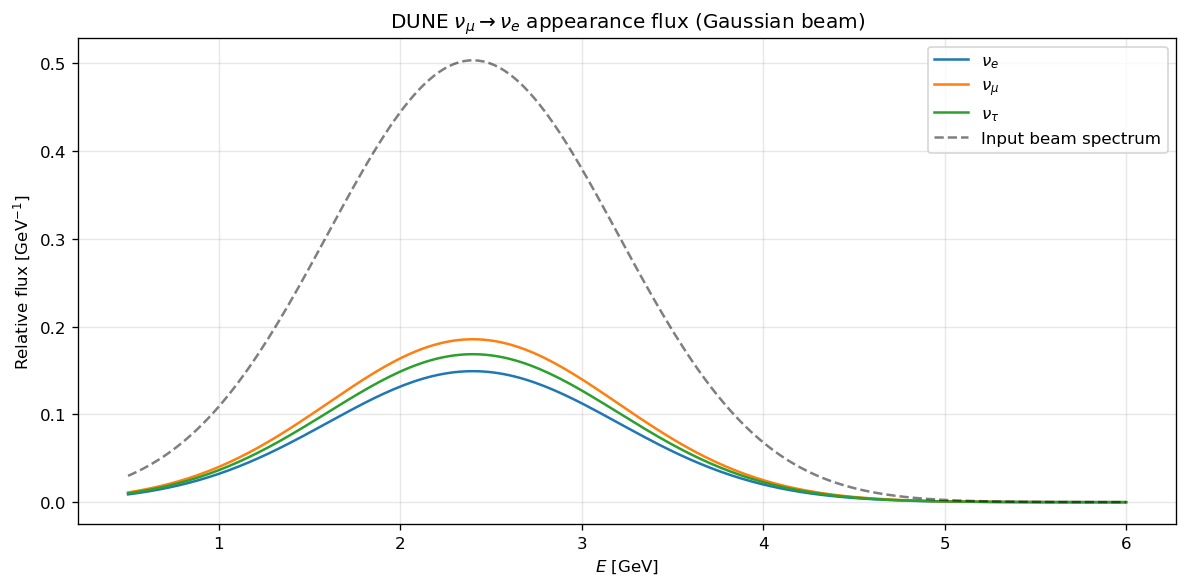

v:\output\analysis\vacuum\vf2_fig43_1_lbl_flux.png


In [9]:
E_dune_GeV = np.linspace(0.5, 6.0, 200)
E_dune_MeV_np = E_dune_GeV * 1e3

# Gaussian beam spectrum centred at 2.4 GeV, width 0.8 GeV
E_beam_center, E_beam_sigma = 2.4, 0.8
spectrum_beam = np.exp(-0.5 * ((E_dune_GeV - E_beam_center) / E_beam_sigma)**2)
spectrum_beam /= numpy_trapezoid(spectrum_beam, E_dune_GeV)

E_t_dune = torch.tensor(E_dune_MeV_np, dtype=ctx.dtype, device=ctx.device)
spec_t_dune = torch.tensor(spectrum_beam, dtype=ctx.dtype, device=ctx.device)

L_dune_t  = torch.tensor(1300.0, dtype=ctx.dtype, device=ctx.device)
nu_mu_state = torch.tensor([0.0 + 0j, 1.0, 0.0], dtype=torch.complex128, device=ctx.device)

flux_dune = to_numpy(vacuum_flux(nu_mu_state, osc, E_t_dune, L_dune_t,
                                  flux=1.0, spectrum=spec_t_dune))

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, color) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
    ax.plot(E_dune_GeV, flux_dune[:, i], label=label, color=color)
ax.plot(E_dune_GeV, spectrum_beam, "k--", alpha=0.5, label="Input beam spectrum")
ax.set_xlabel(r"$E$ [GeV]")
ax.set_ylabel("Relative flux [GeV$^{-1}$]")
ax.set_title(r"DUNE $\nu_\mu \to \nu_e$ appearance flux (Gaussian beam)")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig43_1_lbl_flux.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Atmospheric Neutrinos

### 5.1 P_μμ(E, cos_θz) Heatmap

Two-dimensional heatmap of νμ survival as a function of energy and zenith angle (cos_θz). The
baseline is computed from the zenith angle using the atmospheric geometry formula.

**Expected results:** For downgoing neutrinos (cos_θz > 0) the baseline is short and P_μμ ≈ 1.
For horizontal tracks (cos_θz ≈ 0) the baseline is ~10 000 km and strong oscillations appear.
For upgoing neutrinos (cos_θz = -1), L ≈ 12 740 km and the probability shows complex
multi-frequency oscillations.

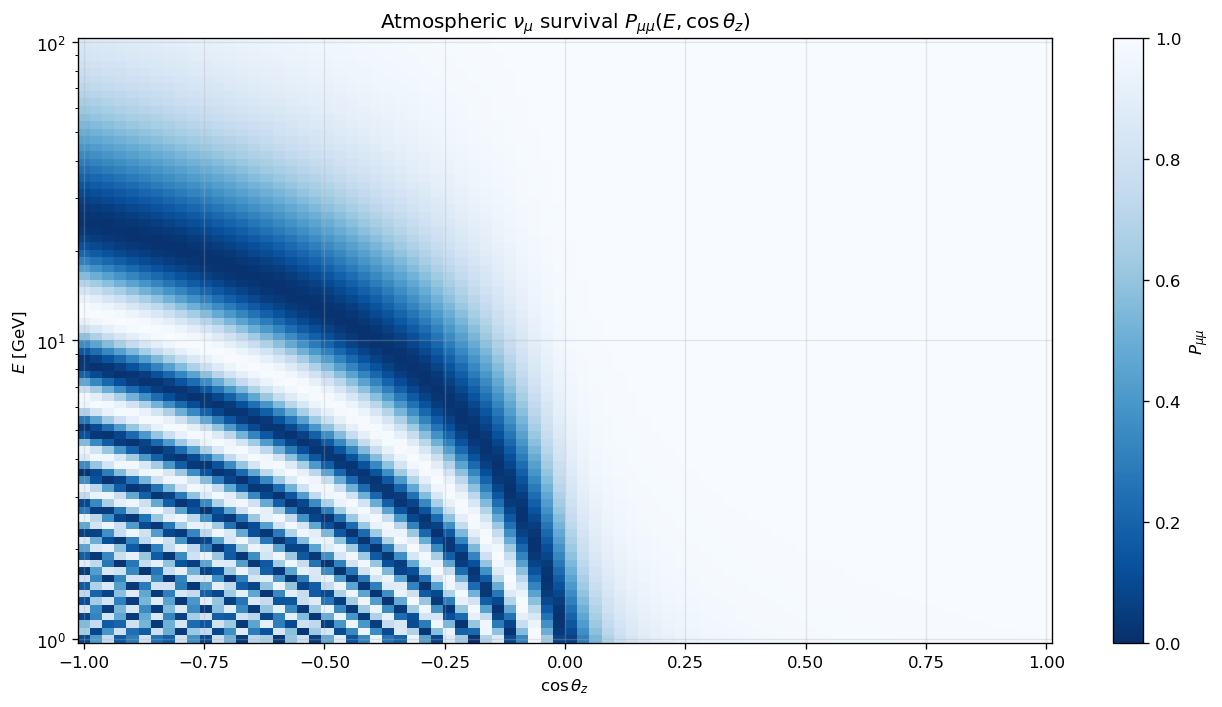

v:\output\analysis\vacuum\vf2_fig51_1_atm_pmu_2d.png


In [10]:
cos_z_vals = np.linspace(-1.0, 1.0, 80)
E_atm_GeV  = np.logspace(0.0, 2.0, 80)   # 1 – 100 GeV
E_atm_MeV  = E_atm_GeV * 1e3

# Compute baselines from zenith angles
L_atm = np.array([baseline_from_zenith(cz) for cz in cos_z_vals])

E_t_atm = torch.tensor(E_atm_MeV, dtype=ctx.dtype, device=ctx.device)
L_t_atm = torch.tensor(L_atm,     dtype=ctx.dtype, device=ctx.device)

# 2-D grid: (NE, 1) × (1, Ncz) → (NE, Ncz, 3, 3)
P_atm = vacuum_probability(osc, E_t_atm[:, None], L_t_atm[None, :])  # (NE, Ncz, 3, 3)
P_mm_atm = to_numpy(P_atm[:, :, 1, 1])   # P_mumu, shape (NE, Ncz)

fig, ax = plt.subplots(figsize=(11, 6))
mesh = ax.pcolormesh(cos_z_vals, E_atm_GeV, P_mm_atm, cmap="Blues_r", vmin=0, vmax=1,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu\mu}$")
ax.set_yscale("log")
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel(r"$E$ [GeV]")
ax.set_title(r"Atmospheric $\nu_\mu$ survival $P_{\mu\mu}(E, \cos\theta_z)$")
fig.tight_layout()
save_and_show("vf2_fig51_1_atm_pmu_2d.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 Zenith-Angle Slices

Slices of P_μμ and P_μe vs energy at cos_θz = -1 (upward, L ≈ 12 740 km), 0 (horizontal,
L ≈ 10 700 km), and +0.9 (downward, L ≈ 20 km).

**Expected results:** For the downward-going slice (cos_θz = +0.9, L ≈ 20 km), P_μμ ≈ 1 at all
energies — barely any oscillation. For the upward-going slice, rapid oscillations driven by
Δm²_31 appear above ~1 GeV, and Δm²_21 modulates the lower energy range.

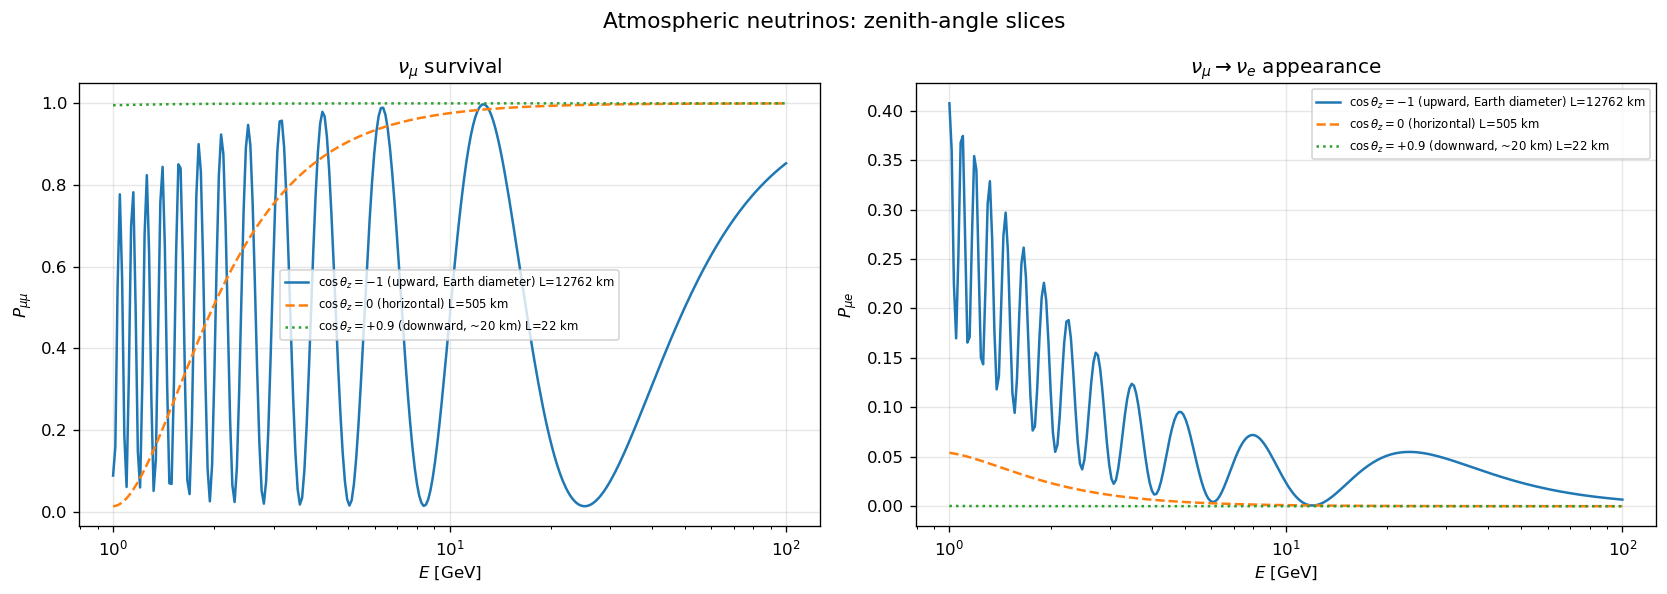

v:\output\analysis\vacuum\vf2_fig52_1_atm_zenith_slices.png


In [11]:
cos_z_slices = {
    r"$\cos\theta_z=-1$ (upward, Earth diameter)": (-1.0, "C0", "-"),
    r"$\cos\theta_z=0$ (horizontal)":              ( 0.0, "C1", "--"),
    r"$\cos\theta_z=+0.9$ (downward, ~20 km)":    ( 0.9, "C2", ":"),
}

E_slice = torch.logspace(0.0, 2.0, 300, dtype=ctx.dtype, device=ctx.device)  # GeV
E_slice_GeV = to_numpy(E_slice)
E_slice_MeV = E_slice * 1e3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, (cz, color, ls) in cos_z_slices.items():
    L_val = baseline_from_zenith(cz)
    L_t   = torch.tensor(L_val, dtype=ctx.dtype, device=ctx.device)
    P_s   = vacuum_probability(osc, E_slice_MeV, L_t)   # (300, 3, 3)
    P_mm  = to_numpy(P_s[:, 1, 1])
    P_me  = to_numpy(P_s[:, 0, 1])
    axes[0].semilogx(E_slice_GeV, P_mm, label=f"{label} L={L_val:.0f} km",
                     color=color, ls=ls)
    axes[1].semilogx(E_slice_GeV, P_me, label=f"{label} L={L_val:.0f} km",
                     color=color, ls=ls)
for ax, title, ylabel in zip(axes,
                               [r"$\nu_\mu$ survival", r"$\nu_\mu \to \nu_e$ appearance"],
                               [r"$P_{\mu\mu}$", r"$P_{\mu e}$"]):
    ax.set_xlabel(r"$E$ [GeV]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)
fig.suptitle("Atmospheric neutrinos: zenith-angle slices", fontsize=13)
fig.tight_layout()
save_and_show("vf2_fig52_1_atm_zenith_slices.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Summary

| Experiment | Baseline | E_peak | P_μμ min | P_μe max |
|---|---|---|---|---|
| Reactor near (1.5 km) | 1.5 km | 3 MeV eff. | ≈ 1.0 | – |
| Daya Bay (50 km) | 50 km | 3 MeV eff. | ≈ 0.95 | – |
| KamLAND (180 km) | 180 km | 3 MeV eff. | ≈ 0.5 | – |
| T2K | 295 km | 0.6 GeV | ≈ 0.05 | ≈ 0.05 |
| NOvA | 810 km | 1.8 GeV | ≈ 0.05 | ≈ 0.07 |
| DUNE | 1300 km | 2.5 GeV | ≈ 0.05 | ≈ 0.09 |
| Atmospheric (upgoing) | ~12 740 km | 1–10 GeV | oscillates | oscillates |

**Physical interpretation:**
- Reactor experiments at short baselines (~50 km) measure sin²(2θ_13) from the disappearance
  dip in the ν̄e spectrum. KamLAND at ~180 km confirmed the Large Mixing Angle (LMA) solution
  with Δm²_21 from the L/E dependence.
- Long-baseline accelerator experiments tune L/E to the first oscillation maximum. DUNE's
  wide-band beam covers both the first and second maxima, breaking degeneracies between δ_CP
  and the mass ordering.
- Atmospheric neutrinos cover a vast range of L/E from 10 m/MeV (downgoing) to 13 000 km/GeV
  (upgoing through Earth), providing sensitivity to both Δm²_21 and Δm²_31 simultaneously.
  Matter effects (not included in these vacuum calculations) become important for upgoing
  atmospheric neutrinos above ~5 GeV.